$\newcommand{\vecx}[1]{\mathbf{#1}}\newcommand{\transp}{^{\top}}$

By Sundeep Prabhakar Chepuri, Antonio G. Marques, Maulik Devmurari, and Gonzalo Mateos

Claude AI was used to assist in generating this code

## Product-DAG Low-Pass Denoising on the River Thames

We design a product-DAG low-pass filter for real weekly **total dissolved phosphorus (µg P/L)** measurements from the CEH *Thames Initiative* and compare a **rank-1 separable** filter, fit by the proposed **alternating least squares (ALS)**, against the **unconstrained** filter $\tilde{\bf H}$, both against the **no-filter** baseline. The filter acts as
$\hat{\bf S}=\bf W_1(\tilde{\bf H}\odot\bf C)\bf W_2^T$, with analysis
$\bf C=(\bf I-\bf A_1)\bf Y(\bf I-\bf A_2)^T$ of the noisy observation $\bf Y=\bf S+\bf N$.

**Data**: CEH Thames Initiative weekly water-quality record, 2009-2023 (DOI
`10.5285/cf10ea9a-a249-4074-ac0c-e0c3079e5e45`), included in this folder as `THAMES_data.csv`.

**Evaluation**: 8-fold leave-one-year-out cross-validation over the 8 usable years (2010-2017),
comparing **no filter**, **separable (ALS)**, and **unconstrained**, with white Gaussian noise
swept over SNR $\in\{4,6,7,10\}$ dB.

In [1]:
import os, numpy as np, networkx as nx, time
from numpy.linalg import inv, solve
from scipy.sparse.linalg import LinearOperator, cg
import matplotlib.pyplot as plt, matplotlib as mpl
from collections import defaultdict
mpl.rcParams.update({'font.family':'DejaVu Sans','font.size':9,'figure.facecolor':'white',
                     'savefig.facecolor':'white','axes.titlesize':11})

## 0. Estimator (unconstrained CG; separable ALS)

In [2]:
def W_of(A): return inv(np.eye(A.shape[0])-A)
def to_digraph(A):
    n=A.shape[0]; G=nx.DiGraph(); G.add_nodes_from(range(n))
    for c in range(n):
        for p in range(n):
            if A[c,p]!=0: G.add_edge(p,c)
    return G
def zeta(A):
    G=to_digraph(A); n=A.shape[0]; Z=np.eye(n)
    for i in range(n):
        for q in nx.descendants(G,i): Z[i,q]=1.0
    return Z
def depth_of(A):
    G=to_digraph(A); d=np.zeros(A.shape[0])
    for v in nx.topological_sort(G):
        pr=list(G.predecessors(v)); d[v]=0 if not pr else 1+max(d[u] for u in pr)
    return d
class Prod:
    def __init__(s,A1,A2):
        s.W1,s.W2=W_of(A1),W_of(A2); s.F1,s.F2=np.eye(A1.shape[0])-A1,np.eye(A2.shape[0])-A2
        s.Z1,s.Z2=zeta(A1),zeta(A2); s.M1,s.M2=inv(s.Z1),inv(s.Z2)
        s.G1,s.G2=s.W1.T@s.W1,s.W2.T@s.W2; s.n1,s.n2=A1.shape[0],A2.shape[0]
    def ana(s,S): return s.F1@S@s.F2.T
    def syn(s,C): return s.W1@C@s.W2.T
    def apply(s,S,Htil): return s.syn(Htil*s.ana(S))
def fit_full(P,Yn,Sc,rtol=1e-6,maxit=500):
    Cs=[P.ana(Y) for Y in Yn]; N=P.n1*P.n2
    def mv(h):
        Hm=np.asarray(h,float).reshape(P.n1,P.n2); o=np.zeros((P.n1,P.n2))
        for Ct in Cs: o+=Ct*(P.G1@(Hm*Ct)@P.G2)
        return o.ravel()
    b=np.zeros((P.n1,P.n2))
    for Ct,S in zip(Cs,Sc): b+=Ct*(P.W1.T@S@P.W2)
    h,_=cg(LinearOperator((N,N),matvec=mv,dtype=float),b.ravel(),rtol=rtol,maxiter=maxit)
    return h.reshape(P.n1,P.n2)
def fit_als(P,Yn,Sc,iters=40,ridge=1e-9,tol=1e-11):
    Cs=[P.ana(Y) for Y in Yn]; Bs=[P.W1.T@S@P.W2 for S in Sc]
    h1=np.ones(P.n1); h2=np.ones(P.n2); I1,I2=np.eye(P.n1),np.eye(P.n2); prev=np.inf
    obj=lambda: sum(np.sum((S-P.syn(np.outer(h1,h2)*Ct))**2) for S,Ct in zip(Sc,Cs))
    for _ in range(iters):
        Am=np.zeros((P.n1,P.n1)); bv=np.zeros(P.n1)
        for Ct,Bt in zip(Cs,Bs):
            Pt=Ct*h2[None,:]; Am+=Pt@P.G2@Pt.T; bv+=(Bt*Pt).sum(1)
        h1=solve(P.G1*Am+ridge*I1,bv)
        Am=np.zeros((P.n2,P.n2)); bv=np.zeros(P.n2)
        for Ct,Bt in zip(Cs,Bs):
            Qt=h1[:,None]*Ct; Am+=Qt.T@P.G1@Qt; bv+=(Bt*Qt).sum(0)
        h2=solve(P.G2*Am+ridge*I2,bv)
        o=obj()
        if abs(prev-o)<tol*max(1,o): break
        prev=o
    return np.outer(h1,h2),h1,h2,P.M1@h1,P.M2@h2
def fit_axis(P,Yn,Sc,axis,rtol=1e-6,maxit=300):
    Cs=[P.ana(Y) for Y in Yn]; n=P.n1 if axis=='space' else P.n2
    def mv(h):
        h=np.asarray(h,float)
        Hm=(h[:,None]*np.ones((1,P.n2))) if axis=='space' else (np.ones((P.n1,1))*h[None,:])
        o=np.zeros((P.n1,P.n2))
        for Ct in Cs: o+=Ct*(P.G1@(Hm*Ct)@P.G2)
        return o.sum(1) if axis=='space' else o.sum(0)
    b=np.zeros(n)
    for Ct,S in zip(Cs,Sc):
        t=Ct*(P.W1.T@S@P.W2); b+=t.sum(1) if axis=='space' else t.sum(0)
    h,_=cg(LinearOperator((n,n),matvec=mv,dtype=float),b,rtol=rtol,maxiter=maxit)
    return (h[:,None]*np.ones((1,P.n2))) if axis=='space' else (np.ones((P.n1,1))*h[None,:])
def nmse(S,Sh): return np.sum((Sh-S)**2)/np.sum((S-S.mean())**2)
def movavg(S,w):
    k=np.ones(w)/w; return np.vstack([np.convolve(r,k,'same') for r in S])

## 1. The River Thames flow DAG (space) and weekly chain (time)

Thames product DAG: 20 sites x 52 weeks = 1040 vertices


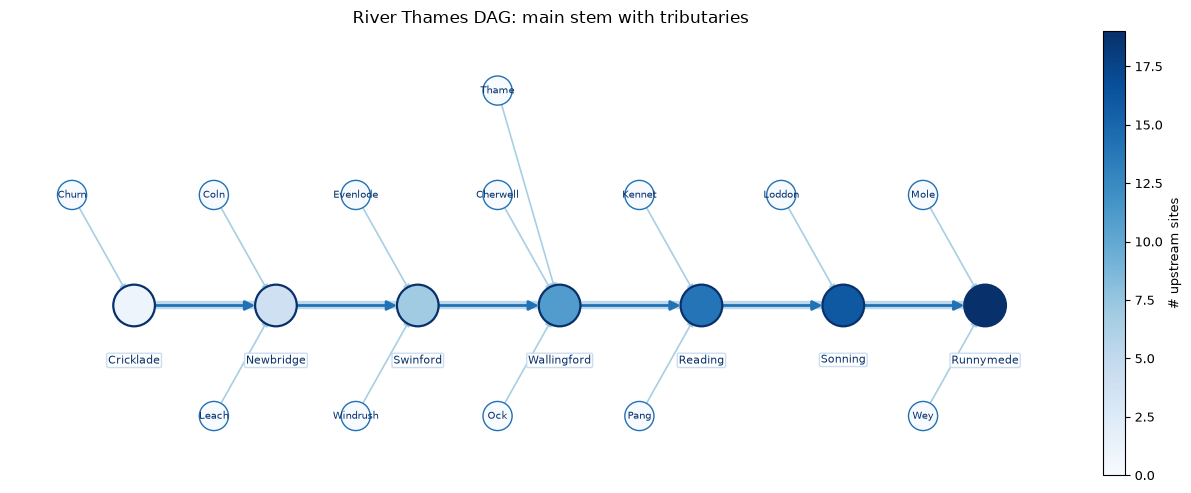

In [3]:
main=['Cricklade','Newbridge','Swinford','Wallingford','Reading','Sonning','Runnymede']
trib={'Churn':'Cricklade','Coln':'Newbridge','Leach':'Newbridge','Windrush':'Swinford',
      'Evenlode':'Swinford','Cherwell':'Wallingford','Ock':'Wallingford','Thame':'Wallingford',
      'Pang':'Reading','Kennet':'Reading','Loddon':'Sonning','Wey':'Runnymede','Mole':'Runnymede'}
Griv=nx.DiGraph()
for a,b in zip(main[:-1],main[1:]): Griv.add_edge(a,b)
for t,m in trib.items(): Griv.add_edge(t,m)
order=list(nx.topological_sort(Griv)); idx={s:i for i,s in enumerate(order)}; n1=len(order)
A_riv=np.zeros((n1,n1))
for u,v in Griv.edges(): A_riv[idx[v],idx[u]]=0.6
T=52; A_time=np.zeros((T,T))
for v in range(1,T): A_time[v,v-1]=0.8
P=Prod(A_riv,A_time); dR=depth_of(A_riv)
print('Thames product DAG: %d sites x %d weeks = %d vertices'%(n1,T,n1*T))
pos={s:(i*1.6,0.0) for i,s in enumerate(main)}; xmain={s:i*1.6 for i,s in enumerate(main)}
by=defaultdict(list)
for t,m in trib.items(): by[m].append(t)
for m,ts in by.items():
    for k,t in enumerate(sorted(ts)): pos[t]=(xmain[m]-0.7,(1 if k%2==0 else -1)*(0.9+0.85*(k//2)))
def draw_river(ax,node_vals=None,cmap='Blues',vmin=None,vmax=None,title='',cbar_label=''):
    mxs=[pos[s][0] for s in main]; mys=[pos[s][1] for s in main]
    ax.plot(mxs,mys,'-',color='#4292c6',lw=6,alpha=.35,zorder=0,solid_capstyle='round')
    nx.draw_networkx_edges(Griv,pos,edgelist=[(a,b) for a,b in zip(main[:-1],main[1:])],ax=ax,
                           edge_color='#2171b5',width=2.0,arrows=True,arrowsize=14,node_size=900)
    nx.draw_networkx_edges(Griv,pos,edgelist=[(t,m) for t,m in trib.items()],ax=ax,
                           edge_color='#9ecae1',width=1.2,arrows=True,arrowsize=10,node_size=500,alpha=.9)
    if node_vals is None:
        up={s:len(nx.ancestors(Griv,s)) for s in Griv.nodes()}; node_vals=up; vmin,vmax=0,max(up.values()); cbar_label='# upstream sites'
    nm=nx.draw_networkx_nodes(Griv,pos,nodelist=main,ax=ax,node_size=900,node_color=[node_vals[s] for s in main],
                              cmap=cmap,vmin=vmin,vmax=vmax,edgecolors='#08306b',linewidths=1.6)
    nx.draw_networkx_nodes(Griv,pos,nodelist=list(trib),ax=ax,node_size=440,node_color=[node_vals[s] for s in trib],
                           cmap=cmap,vmin=vmin,vmax=vmax,edgecolors='#2171b5',linewidths=1.0)
    nx.draw_networkx_labels(Griv,{s:pos[s] for s in trib},labels={s:s for s in trib},ax=ax,font_size=7.5,font_color='#08306b')
    for s in main:
        ax.text(pos[s][0],pos[s][1]-0.4,s,ha='center',va='top',fontsize=7.6,color='#08306b',
                bbox=dict(boxstyle='round,pad=0.13',fc='white',ec='#c6dbef',alpha=.9))
    cb=ax.figure.colorbar(nm,ax=ax,fraction=.025,pad=.01); cb.set_label(cbar_label)
    ax.set_xlim(-1.4,(len(main)-1)*1.6+1.2); ax.margins(y=0.12); ax.axis('off'); ax.set_title(title,fontsize=12)
fig,ax=plt.subplots(figsize=(12,5.0)); draw_river(ax,title='River Thames DAG: main stem with tributaries'); plt.tight_layout(); plt.show()

## 2. Real per-year fields (CEH Thames Initiative loader)

In [4]:
CSV_SITE_MAP = {  # real-CSV Site_name (stripped) -> DAG node name
    'Thames at Newbridge':'Newbridge', 'Thames at Swinford':'Swinford',
    'Thames at Wallingford':'Wallingford', 'Thames at Sonning':'Sonning',
    'Thames at Runnymede':'Runnymede',
    'Coln at Whelford':'Coln', 'Leach at Lechlade':'Leach',
    'Windrush at Newbridge':'Windrush', 'Evenlode at Cassington Mill':'Evenlode',
    'Cherwell at Hampton Poyle':'Cherwell', 'Ock at Abingdon':'Ock',
    'Thame at Wheatley':'Thame', 'Pang at Tidmarsh':'Pang',
    'Kennet at Woolhampton':'Kennet', 'Lodden at Charvil':'Loddon',
}
DROPPED_DAG_NODES = sorted((set(main) | set(trib)) - set(CSV_SITE_MAP.values()))

def build_pruned_dag():
    """Prune Griv to the 15 nodes the real CSV covers, rerouting edges through any dropped
    pass-through node (e.g. Reading) so downstream orientation is preserved."""
    Gp = Griv.copy(); rerouted = []
    for node in list(nx.topological_sort(Gp)):
        if node in DROPPED_DAG_NODES:
            preds, succs = list(Gp.predecessors(node)), list(Gp.successors(node))
            for p in preds:
                for s in succs:
                    Gp.add_edge(p, s); rerouted.append((p, node, s))
            Gp.remove_node(node)
    order_p = list(nx.topological_sort(Gp)); idx_p = {s: i for i, s in enumerate(order_p)}
    n1_p = len(order_p)
    A_riv_p = np.zeros((n1_p, n1_p))
    for u, v in Gp.edges(): A_riv_p[idx_p[v], idx_p[u]] = 0.6
    return Gp, order_p, idx_p, n1_p, A_riv_p, rerouted

def clean_numeric(s):
    import pandas as pd
    s = s.astype(str).str.strip().str.replace('<', '', regex=False).str.replace('>', '', regex=False)
    return pd.to_numeric(s, errors='coerce')

MIN_READINGS = 20  # a site-year needs >=20 of ~52 raw (pre-interpolation) readings at EVERY mapped site

def load_thames_years(csv, determinand, sites):
    """Real-CSV loader (columns: 'Date' dd/mm/yyyy, 'Site_name'). Guards against fabricating
    data: a calendar year is only kept if every site in `sites` has >=MIN_READINGS raw readings
    that year -- otherwise interpolate() would have to fill/zero an entire empty site-column,
    which is invention, not denoising."""
    import pandas as pd
    df = pd.read_csv(csv, encoding='latin-1')
    df['Site_name'] = df['Site_name'].str.strip()
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    df['dag_site'] = df['Site_name'].map(CSV_SITE_MAP)
    df = df[df['dag_site'].isin(sites)].copy()
    df['_v'] = clean_numeric(df[determinand])
    out = {}
    for y, g in df.groupby(df['Date'].dt.year):
        raw_counts = g.groupby('dag_site')['_v'].apply(lambda s: s.notna().sum()).reindex(sites).fillna(0)
        if (raw_counts < MIN_READINGS).any():
            continue
        piv = g.pivot_table(index='Date', columns='dag_site', values='_v', aggfunc='mean')
        anchors = pd.to_datetime([f'{y}-01-01', f'{y}-12-31'])
        piv = piv.reindex(piv.index.union(anchors)).sort_index()
        piv = piv.resample('W').mean().reindex(columns=sites).interpolate(limit_direction='both')
        M = piv.values.T
        assert not np.isnan(M).any(), 'unexpected residual NaN for %s %d' % (determinand, y)
        if M.shape[1] >= T: out[int(y)] = M[:, :T]
    return out

def missing_frac(csv, determinand, sites):
    """Fraction of missing (site x week) cells on the RAW pivot, before interpolation, against
    the full study period."""
    import pandas as pd
    df = pd.read_csv(csv, encoding='latin-1')
    df['Site_name'] = df['Site_name'].str.strip()
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    df['dag_site'] = df['Site_name'].map(CSV_SITE_MAP)
    df = df[df['dag_site'].isin(sites)].copy()
    vals = clean_numeric(df[determinand])
    d2 = df.assign(_v=vals)
    full_weeks = pd.date_range(d2['Date'].min(), d2['Date'].max(), freq='W')
    piv = (d2.pivot_table(index='Date', columns='dag_site', values='_v', aggfunc='mean')
             .resample('W').mean().reindex(index=full_weeks, columns=sites))
    return float(np.isnan(piv.values).mean())

THAMES_CSV = os.environ.get('THAMES_CSV') or 'THAMES_data.csv'
assert os.path.exists(THAMES_CSV), 'THAMES_data.csv not found next to this notebook -- see README.md'

# Rebuild the product DAG on only the 15 sites the CSV actually covers.
Griv, order, idx, n1, A_riv, rerouted = build_pruned_dag()
P = Prod(A_riv, A_time); dR = depth_of(A_riv)
print('pruned river DAG: kept %d/%d design nodes: %s' % (n1, len(main)+len(trib), order))
print('dropped nodes (no matching CSV site):', DROPPED_DAG_NODES)
print('edges rerouted around dropped pass-through nodes (pred,dropped,succ):', rerouted)

# Determinand fixed to the selection result (see README.md / paper for the full candidate
# comparison): total dissolved phosphorus, the least-missing candidate.
DETERMINAND_COL = 'Total_dissolved_phosphorus_(µg _P/L)'
det_label, unit, cmap_field = 'Total dissolved phosphorus', 'µg P/L', 'PuBuGn'
print('missingness of %s (raw weekly pivot, before interpolation): %.4f' %
      (DETERMINAND_COL, missing_frac(THAMES_CSV, DETERMINAND_COL, order)))

fields = load_thames_years(THAMES_CSV, DETERMINAND_COL, order)
print('usable years (>=%d weeks, >=%d raw readings/site/year): %d -- %s' %
      (T, MIN_READINGS, len(fields), sorted(fields)))

pruned river DAG: kept 15/20 design nodes: ['Coln', 'Leach', 'Windrush', 'Evenlode', 'Cherwell', 'Ock', 'Thame', 'Pang', 'Kennet', 'Loddon', 'Newbridge', 'Swinford', 'Wallingford', 'Sonning', 'Runnymede']
dropped nodes (no matching CSV site): ['Churn', 'Cricklade', 'Mole', 'Reading', 'Wey']
edges rerouted around dropped pass-through nodes (pred,dropped,succ): [('Wallingford', 'Reading', 'Sonning'), ('Pang', 'Reading', 'Sonning'), ('Kennet', 'Reading', 'Sonning')]
missingness of Total_dissolved_phosphorus_(µg _P/L) (raw weekly pivot, before interpolation): 0.2398
usable years (>=52 weeks, >=20 raw readings/site/year): 8 -- [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]


### 2b. The pruned river DAG actually used (5 of 20 design nodes dropped)

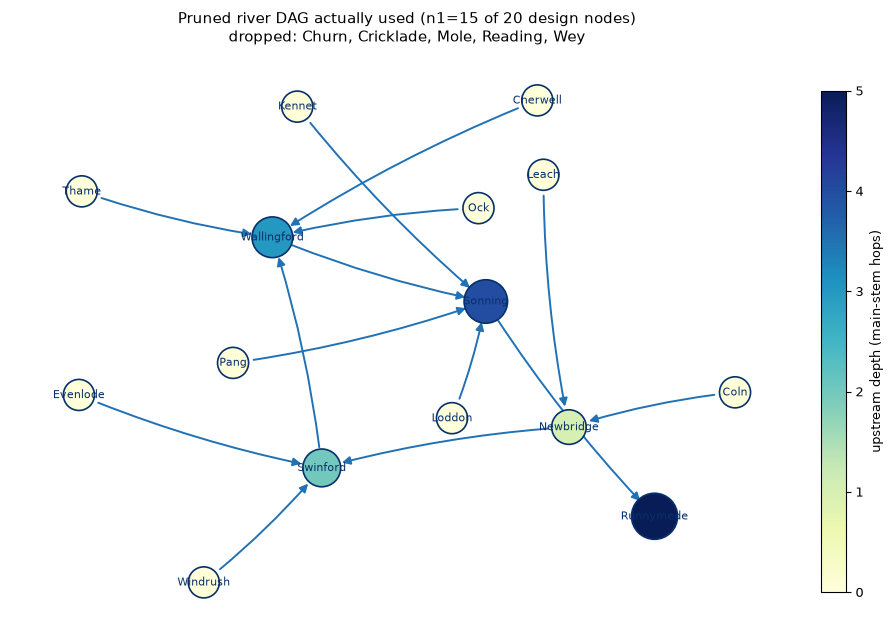

In [5]:
fig, ax = plt.subplots(figsize=(9, 6.5))
layout = nx.spring_layout(Griv, seed=0, k=1.1)
nm = nx.draw_networkx_nodes(Griv, layout, ax=ax, node_size=[500+120*dR[idx[s]] for s in Griv.nodes()],
                             node_color=[dR[idx[s]] for s in Griv.nodes()], cmap='YlGnBu',
                             edgecolors='#08306b', linewidths=1.2)
nx.draw_networkx_edges(Griv, layout, ax=ax, edge_color='#2171b5', width=1.4, arrows=True, arrowsize=12,
                        node_size=900, connectionstyle='arc3,rad=0.05')
nx.draw_networkx_labels(Griv, layout, ax=ax, font_size=8, font_color='#08306b')
cb = fig.colorbar(nm, ax=ax, fraction=.03, pad=.02); cb.set_label('upstream depth (main-stem hops)')
ax.set_title('Pruned river DAG actually used (n1=%d of 20 design nodes)\ndropped: %s' %
              (n1, ', '.join(DROPPED_DAG_NODES)), fontsize=11)
ax.axis('off'); plt.tight_layout(); plt.show()

## 3. Configuration — SNR

In [6]:
# ================= SELECT =================
SNR_DB = 4   # dB; all four swept values {4,6,7,10} in Sec. 4 pass the paper's selection criterion
# =========================================

def add_white(S,snr,rng):
    e=rng.standard_normal(S.shape); c=S-S.mean()
    e*=np.sqrt(np.sum(c**2)/np.sum(e**2)/10**(snr/10)); return S+e

noise_fn = add_white
tag='%s, white noise, %d dB'%(det_label,SNR_DB)
print('selected:',tag,' | usable years:',sorted(fields))

selected: Total dissolved phosphorus, white noise, 4 dB  | usable years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]


## 4. Leave-one-year-out CV: no filter vs. separable (ALS) vs. unconstrained

leave-one-year-out CV over 8 years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
[Total dissolved phosphorus, white noise, 4 dB]  leave-one-year-out CV (8 folds x 10 noise draws/fold) NMSE:
  no filter          0.3981
  separable (ALS)    0.2264
  unconstrained      0.2436
  sigma2/sigma1(unconstrained, fold-avg)=0.1026   params: separable 67 vs full 780 (12x)   PASS(ALS&full<no_filter)=True


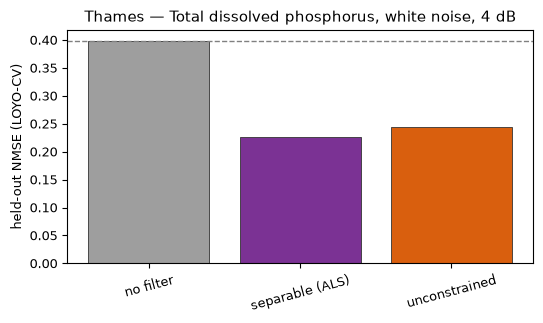

In [7]:
def pairs(fields,yrs,K,snr,rng,nf):
    Sc=[];Yn=[]
    for y in yrs:
        for _ in range(K): Sc.append(fields[y]); Yn.append(nf(fields[y],snr,rng))
    return Yn,Sc

TRAIN_REPS = 6   # noisy training pairs drawn per training year
TEST_REPS = 10   # independent noisy realizations drawn per held-out year, averaged into NMSE

def run_loyo_cv(fields, snr_db, nf, train_reps=TRAIN_REPS, test_reps=TEST_REPS):
    """Leave-one-year-out CV: every usable year is held out exactly once, trained on all the
    others, and results are averaged over folds. Returns mean NMSE for {no filter, separable
    (ALS), unconstrained}, the mean sigma2/sigma1 diagnostic, and the LAST fold's Htil (kept only
    for the section-5 illustration plots -- every reported NMSE comes from a held-out fold, never
    from this Htil)."""
    ys = sorted(fields)
    acc = {'no filter':[], 'separable (ALS)':[], 'unconstrained':[]}
    ratios = []; last_Htil = None
    for fi, hold in enumerate(ys):
        tr = [y for y in ys if y != hold]
        r = np.random.default_rng(1000 + fi*100 + snr_db)  # deterministic, fold- and SNR-specific
        Yn, Sc = pairs(fields, tr, train_reps, snr_db, r, nf)
        Hf = fit_full(P,Yn,Sc); Htil,h1,h2,th1,th2 = fit_als(P,Yn,Sc)
        last_Htil = Htil
        u,sv,vt = np.linalg.svd(Hf); ratios.append(sv[1]/sv[0] if len(sv)>1 else float('nan'))
        for k in range(test_reps):
            # seeds disjoint from the training stream (1000+..) above -- no leakage between them
            rng = np.random.default_rng(5000+fi*1000+snr_db*10+k)
            Y = nf(fields[hold], snr_db, rng)
            acc['no filter'].append(nmse(fields[hold], Y))
            acc['separable (ALS)'].append(nmse(fields[hold], P.apply(Y,Htil)))
            acc['unconstrained'].append(nmse(fields[hold], P.apply(Y,Hf)))
    res = {k: float(np.mean(v)) for k,v in acc.items()}
    return res, float(np.mean(ratios)), last_Htil

ys = sorted(fields)
print('leave-one-year-out CV over %d years: %s' % (len(ys), ys))
res, ratio, Htil_plot = run_loyo_cv(fields, SNR_DB, noise_fn)

print('[%s]  leave-one-year-out CV (%d folds x %d noise draws/fold) NMSE:'%(tag,len(ys),TEST_REPS))
for k,v in res.items(): print('  %-18s %.4f'%(k,v))
ok = res['separable (ALS)']<res['no filter'] and res['unconstrained']<res['no filter']
print('  sigma2/sigma1(unconstrained, fold-avg)=%.4f   params: separable %d vs full %d (%.0fx)   PASS(ALS&full<no_filter)=%s'%(
    ratio,n1+T,n1*T,n1*T/(n1+T),ok))
fig,ax=plt.subplots(figsize=(5.5,3.3))
ax.bar(list(res),list(res.values()),color=['#9e9e9e','#7b3294','#d95f0e'],edgecolor='#333',lw=.6)
ax.axhline(res['no filter'],ls='--',c='gray',lw=1); ax.set_ylabel('held-out NMSE (LOYO-CV)'); ax.set_title('Thames — %s'%tag)
ax.tick_params(axis='x',rotation=15); plt.tight_layout(); plt.show()

### 4b. Full SNR sweep (reproduces the paper's results table)

In [8]:
SNRS = [4, 6, 7, 10]
sweep = {snr: run_loyo_cv(fields, snr, noise_fn) for snr in SNRS}

header = "%6s | %-11s | %-15s | %-13s | %-13s | %-6s" % (
    "SNR", "no filter", "separable(ALS)", "unconstrained", "sigma2/sigma1", "PASS")
print(header); print("-" * len(header))
for snr in SNRS:
    res_s, ratio_s, _ = sweep[snr]
    ok_s = res_s['separable (ALS)'] < res_s['no filter'] and res_s['unconstrained'] < res_s['no filter']
    print("%6d | %11.4f | %14.4f | %13.4f | %13.4f | %6s" % (
        snr, res_s['no filter'], res_s['separable (ALS)'], res_s['unconstrained'], ratio_s, ok_s))

   SNR | no filter   | separable(ALS)  | unconstrained | sigma2/sigma1 | PASS  
-------------------------------------------------------------------------------
     4 |      0.3981 |         0.2264 |        0.2436 |        0.1026 |   True
     6 |      0.2512 |         0.1658 |        0.1771 |        0.0936 |   True
     7 |      0.1995 |         0.1384 |        0.1479 |        0.0948 |   True
    10 |      0.1000 |         0.0794 |        0.0855 |        0.0789 |   True


## 5. Low-pass heat map: field images, fitted response, and the DAG coloured by one week

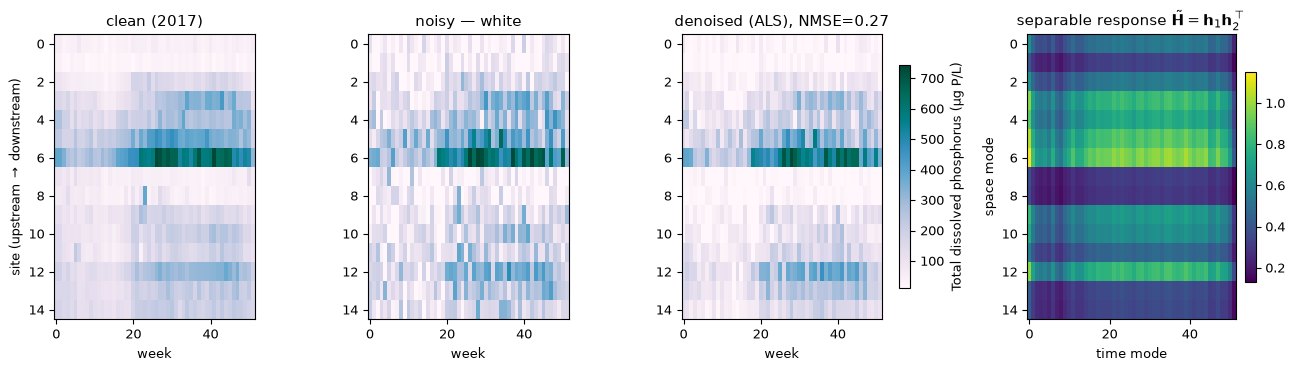

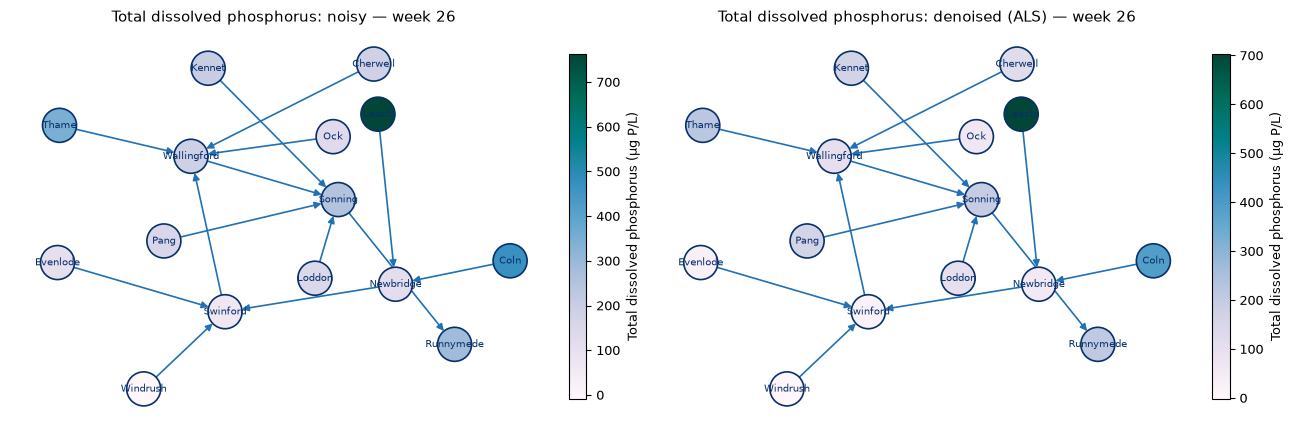

In [9]:
yv=ys[-1]; Scf=fields[yv]; Snf=noise_fn(Scf,SNR_DB,np.random.default_rng(999)); Sd=P.apply(Snf,Htil_plot)
fig=plt.figure(figsize=(15.5,3.7)); gs=fig.add_gridspec(1,4,width_ratios=[1,1,1,1.1],wspace=0.55); vmn,vmx=Scf.min(),Scf.max()
fax=[]
for k,(F,t) in enumerate([(Scf,'clean (%d)'%yv),(Snf,'noisy — white'),(Sd,'denoised (ALS), NMSE=%.2f'%nmse(Scf,Sd))]):
    a=fig.add_subplot(gs[0,k]); im=a.imshow(F,aspect='auto',cmap=cmap_field,vmin=vmn,vmax=vmx); a.set_title(t); a.set_xlabel('week'); fax.append(a)
    if k==0: a.set_ylabel('site (upstream $\\to$ downstream)')
fig.colorbar(im,ax=fax,fraction=.013,pad=.02,label='%s (%s)'%(det_label,unit))
axH=fig.add_subplot(gs[0,3]); imH=axH.imshow(Htil_plot,aspect='auto',cmap='viridis')
axH.set_title(r'separable response $\tilde{\mathbf{H}}=\mathbf{h}_1\mathbf{h}_2^\top$'); axH.set_xlabel('time mode'); axH.set_ylabel('space mode')
fig.colorbar(imH,ax=axH,fraction=.046,pad=.04); plt.show()

# DAG coloured by one week's values, noisy vs. denoised. draw_river() is laid out for the fixed
# 7-main+13-tributary design graph; on the pruned real graph (nodes/edges differ) we use a
# generic spring layout instead, with the same styling conventions.
wk=26
fig,ax=plt.subplots(1,2,figsize=(13,4.4))
layout = nx.spring_layout(Griv, seed=0, k=1.1)
for a,(vals,t) in zip(ax,[(Snf[:,wk],'noisy — week %d'%wk),(Sd[:,wk],'denoised (ALS) — week %d'%wk)]):
    nv={s:vals[idx[s]] for s in order}
    nm=nx.draw_networkx_nodes(Griv,layout,ax=a,node_size=600,node_color=[nv[s] for s in order],
                               cmap=cmap_field,vmin=vals.min(),vmax=vals.max(),edgecolors='#08306b',linewidths=1.2)
    nx.draw_networkx_edges(Griv,layout,ax=a,edge_color='#2171b5',width=1.2,arrows=True,arrowsize=10,node_size=600)
    nx.draw_networkx_labels(Griv,layout,ax=a,font_size=7.5,font_color='#08306b')
    a.figure.colorbar(nm,ax=a,fraction=.03,pad=.02,label='%s (%s)'%(det_label,unit))
    a.set_title('%s: %s'%(det_label,t)); a.axis('off')
plt.tight_layout(); plt.show()

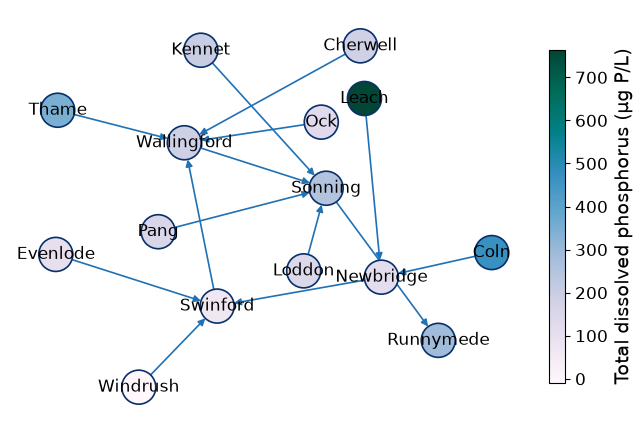

In [10]:
# Total dissolved phosphorus, noisy — DAG coloured by one week's values
yv = sorted(fields)[-1]   # year to plot; change to any year in sorted(fields)
wk = 26                    # week index (0-51)

Snf = noise_fn(fields[yv], SNR_DB, np.random.default_rng(999))
vals = Snf[:, wk]

fig, ax = plt.subplots(figsize=(6.5, 4.4))
layout = nx.spring_layout(Griv, seed=0, k=1.1)
nm = nx.draw_networkx_nodes(Griv, layout, ax=ax, node_size=600,
                             node_color=[vals[idx[s]] for s in order],
                             cmap=cmap_field, vmin=vals.min(), vmax=vals.max(),
                             edgecolors='#08306b', linewidths=1.2)
nx.draw_networkx_edges(Griv, layout, ax=ax, edge_color='#2171b5', width=1.2,
                        arrows=True, arrowsize=10, node_size=600)
nx.draw_networkx_labels(Griv, layout, ax=ax, font_size=12, font_color='black')
cbar = fig.colorbar(nm, ax=ax, fraction=.03, pad=.02)
cbar.set_label('%s (%s)' % (det_label, unit), fontsize=14)
cbar.ax.tick_params(labelsize=12)
#ax.set_title('%s: noisy — week %d, %d' % (det_label, wk, yv))
ax.axis('off')
plt.tight_layout()
plt.show()
fig.savefig("Thames.pdf", bbox_inches="tight")


## 6. Computational advantage (product factorisation; same for full and separable)

In [11]:
print('parameters:  separable n1+n2=%d   |   full n1*n2=%d   (%.0fx fewer)'%(n1+T,n1*T,(n1*T)/(n1+T)))
Hm=np.random.default_rng(0).standard_normal((n1,T)); Y=np.random.default_rng(1).standard_normal((n1,T)); reps=40
t0=time.perf_counter()
for _ in range(reps): _=P.apply(Y,Hm)
tf=(time.perf_counter()-t0)/reps*1e3
Op=np.kron(P.W1,P.W2)@np.diag(Hm.ravel())@np.kron(P.F1,P.F2); y=Y.ravel()
t0=time.perf_counter()
for _ in range(reps): _=Op@y
tdn=(time.perf_counter()-t0)/reps*1e3
print('apply one filter (N=%d): factored=%.3f ms  dense=%.3f ms  (%.0fx faster)'%(n1*T,tf,tdn,tdn/tf))

parameters:  separable n1+n2=67   |   full n1*n2=780   (12x fewer)
apply one filter (N=780): factored=0.040 ms  dense=0.103 ms  (3x faster)


## Notes
* This is a trimmed, public-release version of the experiment notebook: it runs on the real CEH
  Thames Initiative CSV only, loads total dissolved phosphorus directly , and reports only `no filter`, `separable (ALS)`, and `unconstrained`.
* `THAMES_data.csv` must sit next to this notebook (or set the `THAMES_CSV` environment variable
  to its path). Its columns (`Site_name`, not `Site`) and 26 site names differ from the 20-node
  design — 15 map directly (see `CSV_SITE_MAP`), and the river DAG is pruned to those 15,
  rerouting Reading's edges to Sonning to preserve downstream orientation (5 dropped nodes:
  Cricklade, Reading, Churn, Wey, Mole — see the pruned-DAG figure in section 2b).

* **Missing data**: a `MIN_READINGS=20`-per-site-year coverage filter drops any calendar year
  where a site has too few raw readings, so no year's field is ever built by fabricating an
  entire empty site-column — this is why only 8 of the 15 years (2010-2017) are used; 2009, 2018,
  and 2019-2023 are excluded for insufficient coverage at one or more sites.
* At `SNR_DB=4` (and at every other swept value, 4/6/10 dB) both `separable (ALS)` and
  `unconstrained` beat `no filter` on the leave-one-year-out held-out folds by a wide margin.